### Import Libraries


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import MinMaxScaler
import time
from sklearn.neighbors import KNeighborsRegressor


### Load the train Dataset

In [34]:

df = pd.read_csv('datasets/X_train.csv')

# Basic EDA

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\Column info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

<>:9: SyntaxWarning: invalid escape sequence '\C'
<>:9: SyntaxWarning: invalid escape sequence '\C'
/var/folders/nc/mqmty3mn2r37_yfynvw8z5nw0000gn/T/ipykernel_66460/2600508371.py:9: SyntaxWarning: invalid escape sequence '\C'
  print("\Column info:")


Dataset shape: (1285000, 14)

First few rows:
          t       x_1       y_1     v_x_1     v_y_1       x_2       y_2  \
0  0.000000  1.000000  0.000000  0.000000  0.000000 -0.266467  0.859196   
1  0.039062  0.999548  0.000092 -0.023159  0.004731 -0.266261  0.858781   
2  0.078125  0.998190  0.000370 -0.046362  0.009474 -0.265641  0.857535   
3  0.117188  0.995925  0.000833 -0.069654  0.014239 -0.264606  0.855456   
4  0.156250  0.992747  0.001483 -0.093080  0.019040 -0.263154  0.852540   

      v_x_2     v_y_2       x_3       y_3     v_x_3     v_y_3  Id  
0  0.000000  0.000000 -0.733533 -0.859196  0.000000  0.000000   0  
1  0.010574 -0.021257 -0.733287 -0.858874  0.012584  0.016526   1  
2  0.021172 -0.042552 -0.732549 -0.857905  0.025189  0.033078   2  
3  0.031817 -0.063924 -0.731318 -0.856289  0.037837  0.049685   3  
4  0.042533 -0.085412 -0.729592 -0.854022  0.050548  0.066372   4  
\Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1285000 entries, 0 to 1284999
D

### Correlation Analysis

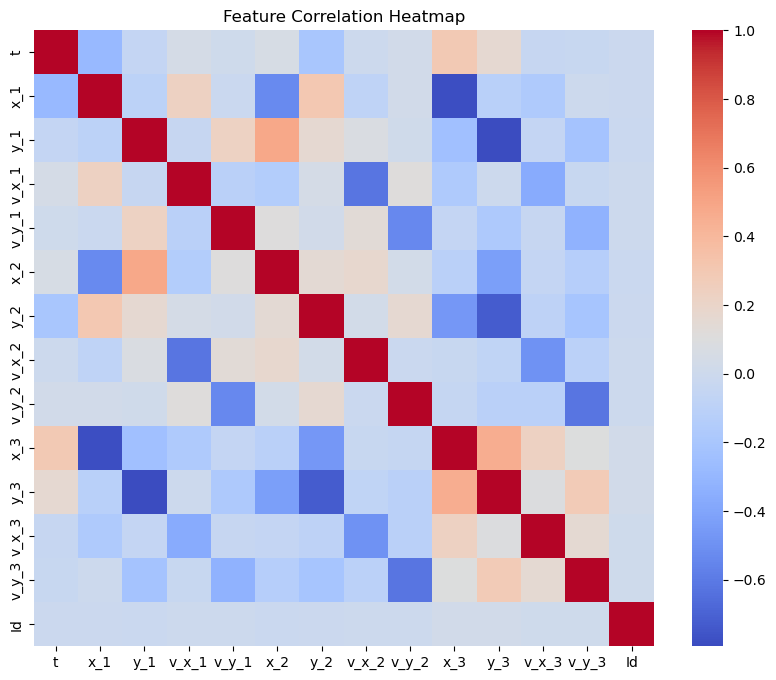

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

### Visualize trajectories

Random trajectory index: 2524
Plot index: range(799013, 799270)
Plotting trajectory starting at index: 799013


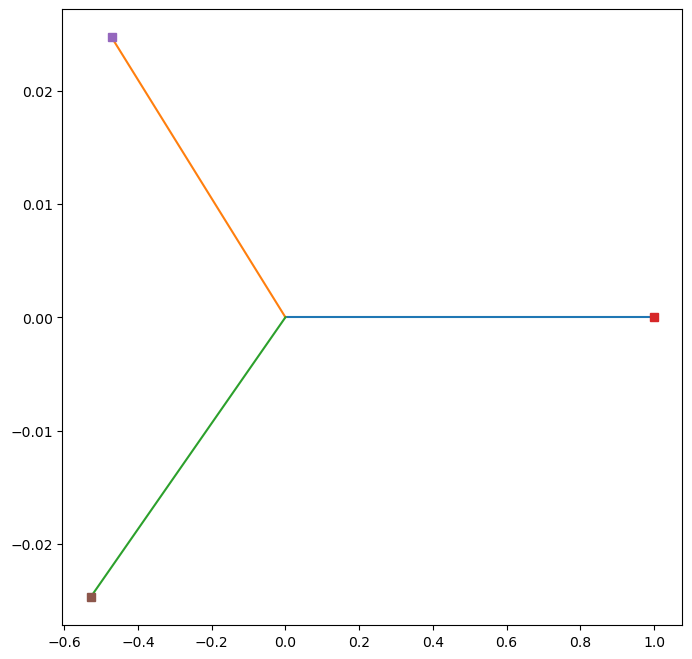

In [36]:
# Keep in mind each trajectory last until t = 10
idx = np.hstack((0, df[df.t == 10].index.values + 1)) # indices where each trajectory starts

#Pick a random trajectory starting index (index of the starting points indexes array)
k = np.random.randint(idx.shape[0])
print("Random trajectory index:", k)

# Get the indices in the actual dataset for the trajectory to plot (assuming 256 time steps per trajectory)
pltidx = range(idx[k], 257 + idx[k])
pltsquare = idx[k] # Starting point
print("Plot index:", pltidx)
print("Plotting trajectory starting at index:", pltsquare)

#Plot the trajectory
plt.figure(figsize=(8, 8))
plt.plot(df.x_1[pltidx], df.y_1[pltidx])
plt.plot(df.x_2[pltidx], df.y_2[pltidx])
plt.plot(df.x_3[pltidx], df.y_3[pltidx])

plt.plot(df.x_1[pltsquare], df.y_1[pltsquare], 's')
plt.plot(df.x_2[pltsquare], df.y_2[pltsquare], 's')
plt.plot(df.x_3[pltsquare], df.y_3[pltsquare], 's')


## 1.Build a baseline Linear Regression Model
#### Here we add the initial position of each of the 3 bodies as new column for every "simulation"

In [37]:
# Add the initial positions of every simulation as a new column
init_cols = ['x1_init', 'y1_init',  'x2_init', 'y2_init',  'x3_init', 'y3_init']

# Initialize with NaNs
for col in init_cols:
    df[col] = np.nan

# For rows where t == 0.0, set the initial positions
df.loc[df['t'] == 0.0, init_cols] = df.loc[df['t'] == 0.0, ['x_1','y_1','x_2','y_2','x_3','y_3']].values

# Forward fill the initial positions down each trajectory
df[init_cols] = df[init_cols].ffill()

df.head(400)


,t,x_1,y_1,v_x_1,v_y_1,x_2,y_2,v_x_2,v_y_2,x_3,y_3,v_x_3,v_y_3,Id,x1_init,y1_init,x2_init,y2_init,x3_init,y3_init
0,0.000000,1.000000,0.000000,0.000000,0.000000,-0.266467,0.859196,0.000000,0.000000,-0.733533,-0.859196,0.000000,0.000000,0,1.0,0.0,-0.266467,0.859196,-0.733533,-0.859196
1,0.039062,0.999548,0.000092,-0.023159,0.004731,-0.266261,0.858781,0.010574,-0.021257,-0.733287,-0.858874,0.012584,0.016526,1,1.0,0.0,-0.266467,0.859196,-0.733533,-0.859196
2,0.078125,0.998190,0.000370,-0.046362,0.009474,-0.265641,0.857535,0.021172,-0.042552,-0.732549,-0.857905,0.025189,0.033078,2,1.0,0.0,-0.266467,0.859196,-0.733533,-0.859196
3,0.117188,0.995925,0.000833,-0.069654,0.014239,-0.264606,0.855456,0.031817,-0.063924,-0.731318,-0.856289,0.037837,0.049685,3,1.0,0.0,-0.266467,0.859196,-0.733533,-0.859196
4,0.156250,0.992747,0.001483,-0.093080,0.019040,-0.263154,0.852540,0.042533,-0.085412,-0.729592,-0.854022,0.050548,0.066372,4,1.0,0.0,-0.266467,0.859196,-0.733533,-0.859196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,5.390620,-3.950368,1.772472,-0.646835,0.341329,2.122125,-0.812181,0.058909,0.726432,1.828243,-0.960291,0.587926,-1.067761,395,1.0,0.0,-0.176502,0.555739,-0.823498,-0.555739
396,5.429690,-3.975602,1.785790,-0.645157,0.340574,2.118487,-0.787331,-0.236353,0.536747,1.857115,-0.998460,0.881510,-0.877320,396,1.0,0.0,-0.176502,0.555739,-0.823498,-0.555739
397,5.468750,-4.000771,1.799079,-0.643502,0.339829,2.104276,-0.770979,-0.483891,0.290425,1.896495,-1.028101,1.127393,-0.630254,397,1.0,0.0,-0.176502,0.555739,-0.823498,-0.555739
398,5.507810,-4.025876,1.812340,-0.641868,0.339093,2.081273,-0.765539,-0.685589,-0.025412,1.944603,-1.046801,1.327457,-0.313681,398,1.0,0.0,-0.176502,0.555739,-0.823498,-0.555739


### Define features and target variables

In [38]:
# Features and target
X = df[["x1_init","y1_init","x2_init","y2_init","x3_init","y3_init","t"]]
y = df[["x_1","y_1","x_2","y_2","x_3","y_3"]]


### Train the Linear Regression Model

In [39]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape
    
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Evaluate the model

Mean Squared Error: 1.641502
R² Score: 0.103685


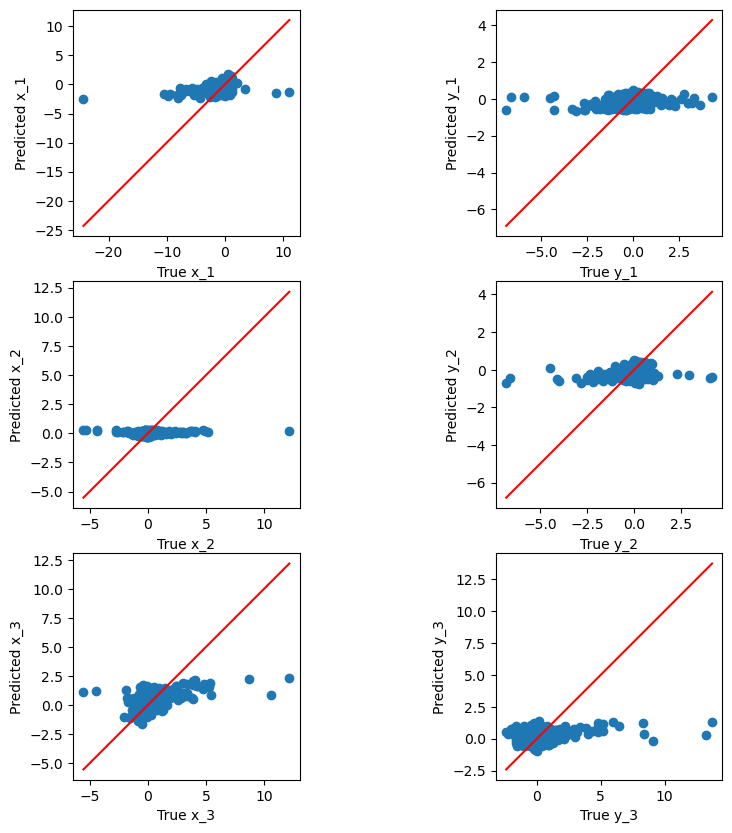

In [40]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.6f}")

def plot_y_yhat(y_test,y_pred, plot_title = "plot"):
    labels = ['x_1','y_1','x_2','y_2','x_3','y_3']
    MAX = 500
    if len(y_test) > MAX:
        idx = np.random.choice(len(y_test),MAX, replace=False)
    else:
        idx = np.arange(len(y_test))
    plt.figure(figsize=(10,10))
    for i in range(6):
        x0 = np.min(y_test[idx,i])
        x1 = np.max(y_test[idx,i])
        plt.subplot(3,2,i+1)
        plt.scatter(y_test[idx,i],y_pred[idx,i])
        plt.xlabel('True '+labels[i])
        plt.ylabel('Predicted '+labels[i])
        plt.plot([x0,x1],[x0,x1],color='red')
        plt.axis('square')
    plt.savefig(plot_title+'.pdf')
    plt.show()
    
plot_y_yhat(y_test.values, y_pred, plot_title = "y_vs_yhat_LR") 

# 2. Polynomial Regression
## 2.1 + 2.2 Build, train and evaluate the model

In [41]:
def validate_poly_regression(X_train, y_train, X_val, y_val, regressor=None, degrees=range(1,15), max_features=None):
    """
    Validate polynomial regression models of various degrees.

    Returns:
        best_model: fitted sklearn pipeline with the best degree
        best_rmse: float, RMSE of the best model
    """
    best_rmse = float('inf')
    best_model = None
    best_degree = None
    
    # Default regressor: simple linear regression
    if regressor is None:
        regressor = LinearRegression()
    
    for degree in degrees:
        print(f"\n🔹 Testing degree {degree}...")
        
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        model = Pipeline([
            ('poly', poly),
            ('scaler', StandardScaler()),
            ('reg', regressor)
        ])
        
        # Train on a subset (optional for speed)
        if max_features is not None and len(X_train) > max_features:
            idx = np.random.choice(len(X_train), max_features, replace=False)
            X_train_sample = X_train[idx]
            y_train_sample = y_train[idx]
        else:
            X_train_sample = X_train
            y_train_sample = y_train
        
        # Fit and predict
        model.fit(X_train_sample, y_train_sample)
        y_pred = model.predict(X_val)
        
        # Compute RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        print(f"   RMSE = {rmse:.4f}")
        print(f"   Features generated: {model.named_steps['poly'].n_output_features_}")
        
        # Keep the best
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_degree = degree
    
    print(f"\n🏆 Best degree = {best_degree}, RMSE = {best_rmse:.4f}")
    return best_model, best_rmse, best_degree



# Get the best polynomial regression model
best_poly_model, best_poly_rmse, best_poly_degree = validate_poly_regression(
    X_train.values, y_train.values, X_test.values, y_test.values,
    regressor=RidgeCV(alphas=[0.1, 1, 10]),
    degrees=range(1,6),
    max_features=5000
)



🔹 Testing degree 1...
   RMSE = 1.2816
   Features generated: 7

🔹 Testing degree 2...
   RMSE = 1.2510
   Features generated: 35

🔹 Testing degree 3...
   RMSE = 1.2121
   Features generated: 119

🔹 Testing degree 4...
   RMSE = 1.1790
   Features generated: 329

🔹 Testing degree 5...
   RMSE = 1.1474
   Features generated: 791

🏆 Best degree = 5, RMSE = 1.1474


# 3. Feature Engineering


### See the features pairplot

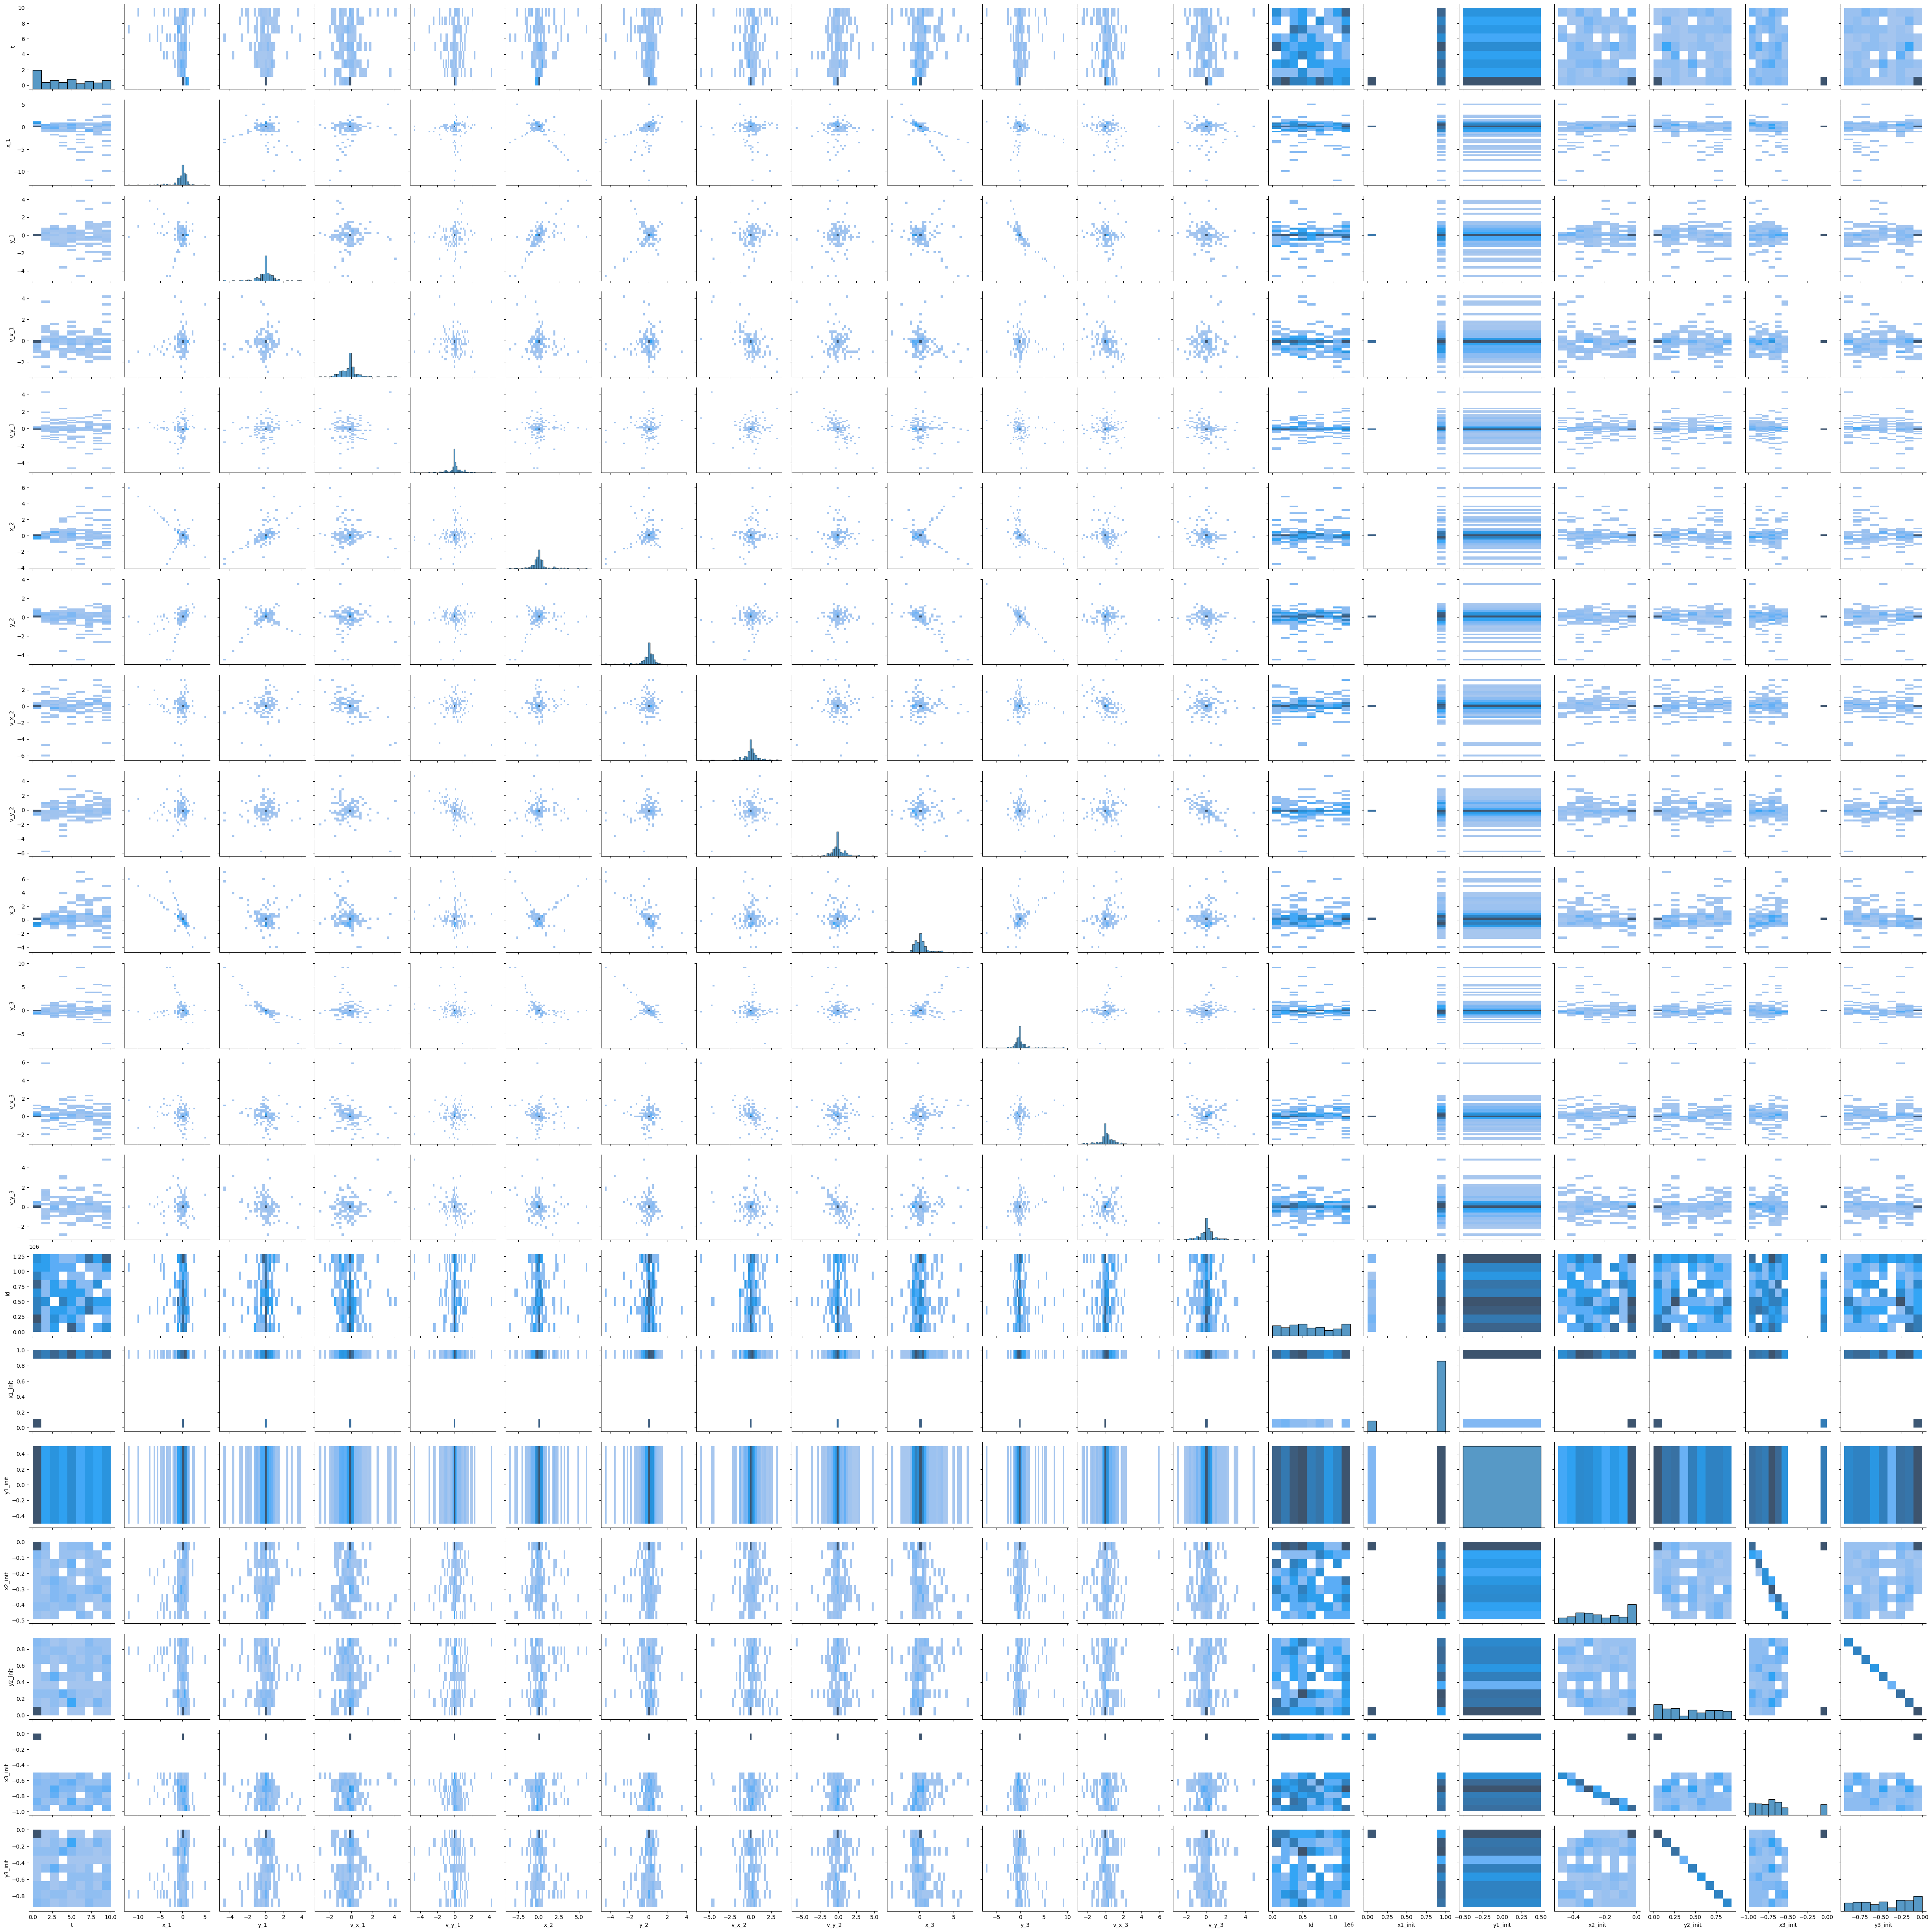

In [42]:
sns.pairplot(df.sample(200), kind="hist")

## 3.1 Removing variables

<Axes: >

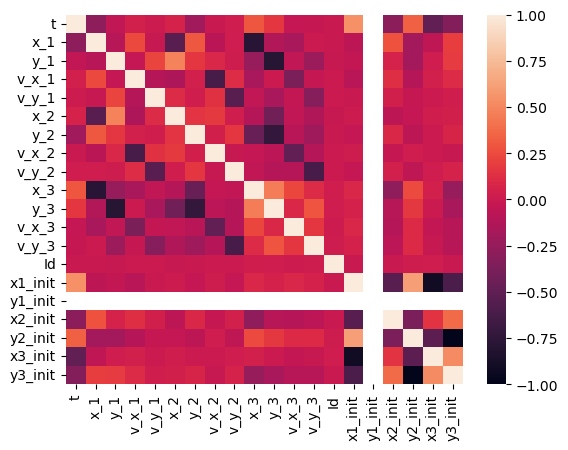

In [43]:
# Get the correlation matrix and plot it
corr = df.corr()
sns.heatmap(corr,annot=False)

### Drop very correlated features, by sorting them by value of correlation, deleting one by one and running the baseline model


🔹 Baseline RMSE with all features: 1.2812

Iteration 1: Dropping 'y2_init' (pair correlation = 1.000)
→ RMSE after dropping 'y2_init': 1.2812


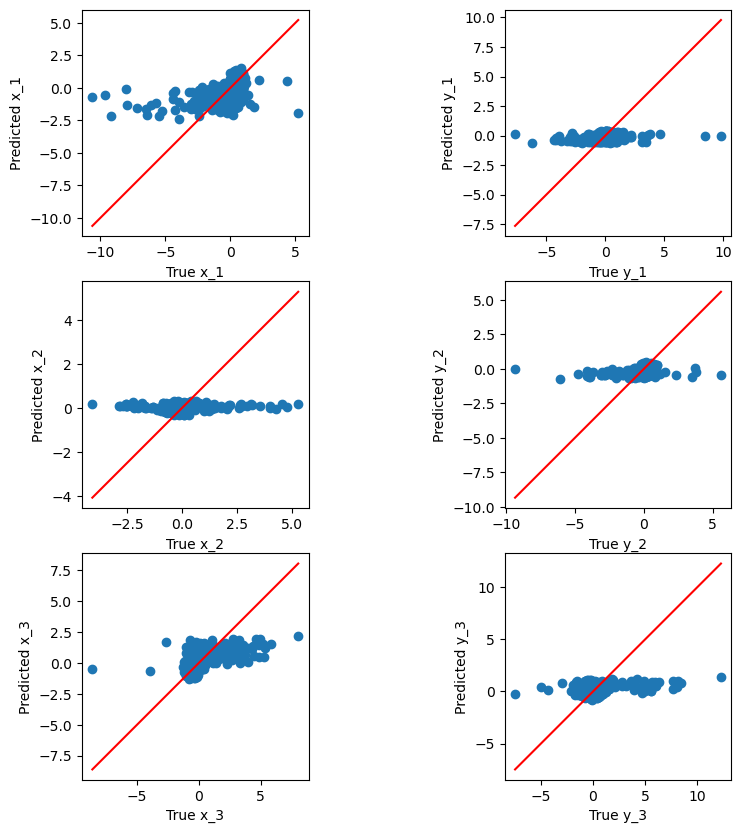


Iteration 2: Dropping 'x3_init' (pair correlation = 0.909)
→ RMSE after dropping 'x3_init': 1.2812


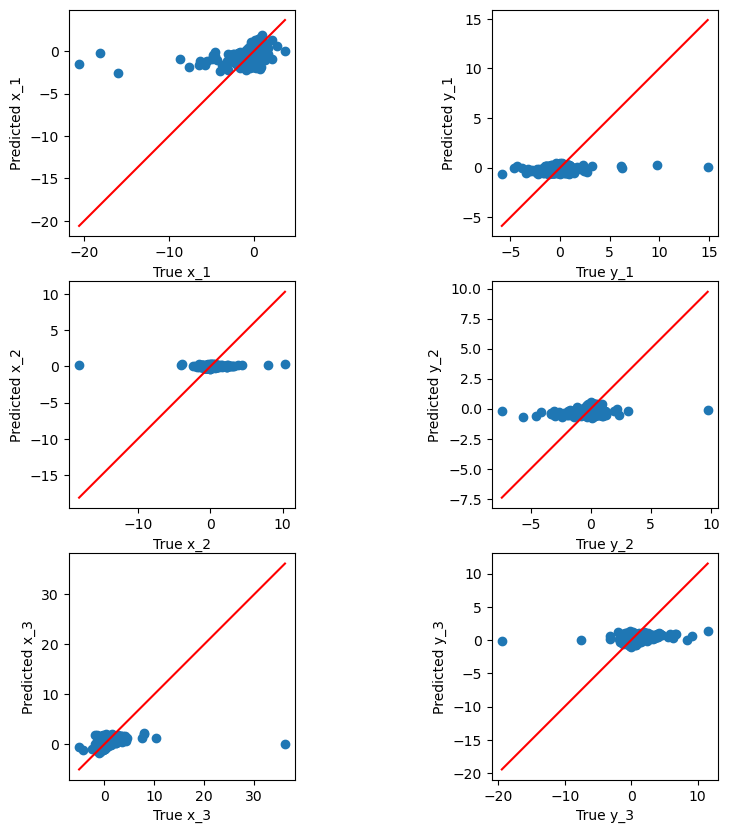


Iteration 3: Dropping 'x1_init' (pair correlation = 0.602)
→ RMSE after dropping 'x1_init': 1.3145


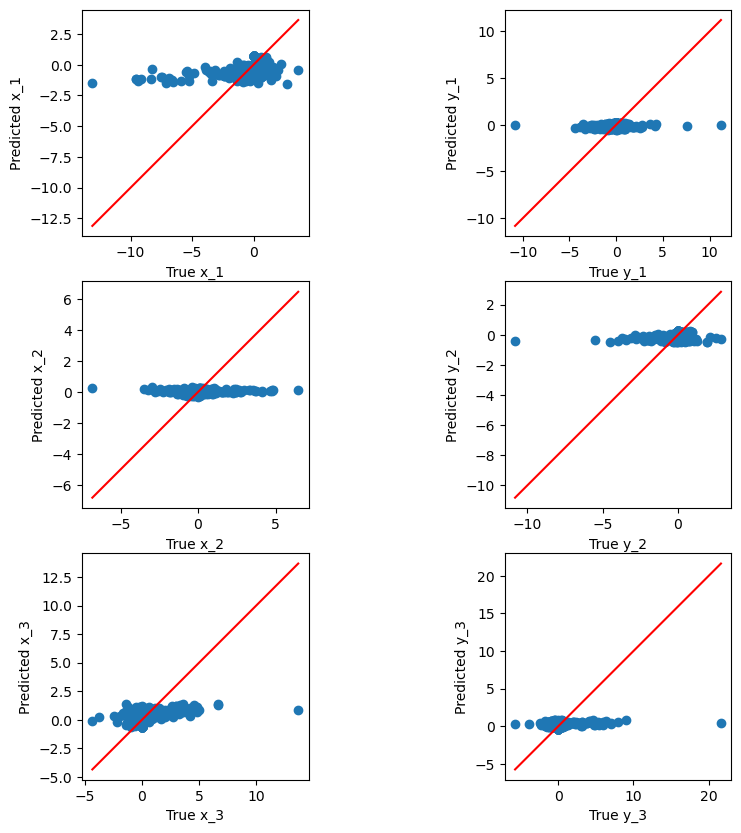

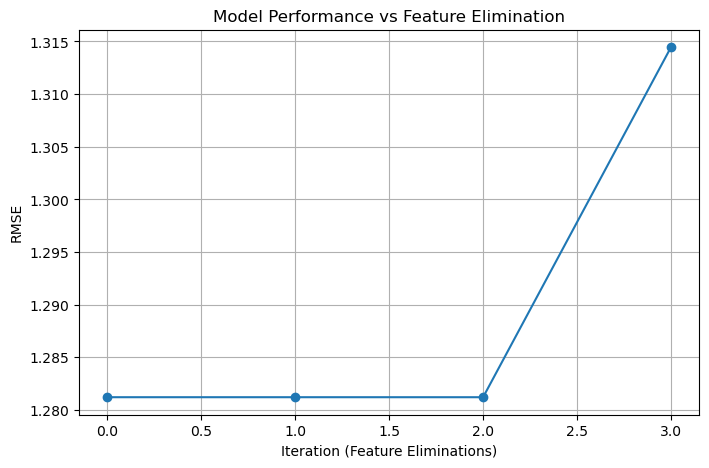


Features dropped: ['y2_init', 'x3_init', 'x1_init']
Remaining features: ['y1_init', 'x2_init', 'y3_init', 't']


In [44]:
# Initialize copies and tracking lists
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()
remaining_features = list(X_train_copy.columns)

# Compute baseline RMSE with the already-fitted model
baseline_rmse = np.sqrt(mse)
rmses = [baseline_rmse]
dropped_features = []

print(f"\n🔹 Baseline RMSE with all features: {baseline_rmse:.4f}")


num_features_to_remove = 3  # number of redundant features to remove

# Iterative redundancy elimination
for iteration in range(num_features_to_remove):
    # Correlation matrix of remaining features
    corr_matrix = X_train_copy[remaining_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find most correlated pair
    max_corr = upper.max().max()
    if np.isnan(max_corr) or max_corr == 0:
        print("No more correlations to remove.")
        break

    pair_idx = np.where(upper == max_corr)
    f1, f2 = upper.columns[pair_idx[1][0]], upper.index[pair_idx[0][0]]

    # Decide which feature to drop based on correlation with target y
    f1_corr_y = np.mean([np.abs(np.corrcoef(X_train_copy[f1], y_train[col])[0,1]) for col in y_train.columns])
    f2_corr_y = np.mean([np.abs(np.corrcoef(X_train_copy[f2], y_train[col])[0,1]) for col in y_train.columns])
    drop_feature = f1 if f1_corr_y < f2_corr_y else f2

    print(f"\nIteration {iteration+1}: Dropping '{drop_feature}' (pair correlation = {max_corr:.3f})")
    remaining_features.remove(drop_feature)
    dropped_features.append(drop_feature)

    # Retrain model without dropped feature
    newModel = LinearRegression()
    newModel.fit(X_train_copy[remaining_features], y_train)
    y_pred = newModel.predict(X_test_copy[remaining_features])
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmses.append(rmse)
    print(f"→ RMSE after dropping '{drop_feature}': {rmse:.4f}")

    # Plot y vs ŷ
    plot_y_yhat(y_test.values, y_pred, plot_title=f"After dropping {drop_feature}")

plt.figure(figsize=(8,5))
plt.plot(range(len(rmses)), rmses, marker='o')
plt.xlabel("Iteration (Feature Eliminations)")
plt.ylabel("RMSE")
plt.title("Model Performance vs Feature Elimination")
plt.grid(True)
plt.show()
print("\nFeatures dropped:", dropped_features)
print("Remaining features:", remaining_features)


## 3.2 Evaluate variable reduction

In [45]:
# Test new feature set in the polynomial regression model
best_poly_degree_less_var, best_poly_model_less_var, best_poly_rmse_less_var = validate_poly_regression(
    X_train[remaining_features].values, y_train.values,
    X_test[remaining_features].values, y_test.values,
    regressor=RidgeCV(alphas=[0.1, 1, 10]),
    degrees=[best_poly_degree]
)



🔹 Testing degree 5...
   RMSE = 1.1416
   Features generated: 125

🏆 Best degree = 5, RMSE = 1.1416


## 3.3 Adding variables

In [46]:
#Normalize velocity and position values
scaler_pos = MinMaxScaler()
df[['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']] = scaler_pos.fit_transform(df[['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']])

scaler_vel = MinMaxScaler()
df[['v_x_1', 'v_y_1', 'v_x_2', 'v_y_2', 'v_x_3', 'v_y_3']] = scaler_vel.fit_transform(df[['v_x_1', 'v_y_1', 'v_x_2', 'v_y_2', 'v_x_3', 'v_y_3']])

# Compute the new initial distance features
df['init_d12'] = np.sqrt((df['x_1'] - df['x_2'])**2 + (df['y_1'] - df['y_2'])**2)
df['init_d23'] = np.sqrt((df['x_2'] - df['x_3'])**2 + (df['y_2'] - df['y_3'])**2)
df['init_d31'] = np.sqrt((df['x_3'] - df['x_1'])**2 + (df['y_3'] - df['y_1'])**2)

# Then normalize them
scaler_dist = MinMaxScaler()
df[['init_d12', 'init_d23', 'init_d31']] = scaler_dist.fit_transform(df[['init_d12', 'init_d23', 'init_d31']])


# Get the scaled features(initial positions and time) and target
X_scaled = df[["x1_init","y1_init","x2_init","y2_init","x3_init","y3_init","t",
        "v_x_1", "v_y_1", "v_x_2", "v_y_2", "v_x_3", "v_y_3",
        "init_d12", "init_d23", "init_d31"]]
y_scaled = df[["x_1","y_1","x_2","y_2","x_3","y_3"]]


# Train/Test split
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Train a linear regression model on the scaled data
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred = model_scaled.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)   
print(f"Linear Regression RMSE (scaled): {rmse:.6f}")
print(f"Linear Regression Mean Squared Error (scaled): {mse:.6f}")
print(f"Linear Regression R² Score (scaled): {r2:.6f}")

#Train a polynomial regression model on the scaled data
best_poly_model_scaled, best_poly_rmse_scaled, best_poly_degree_scaled = validate_poly_regression(
    X_train_scaled.values, y_train.values, X_test_scaled.values, y_test.values,
    regressor=RidgeCV(alphas=[0.1, 1, 10]),
    degrees=range(1,4), ## Reduced max degree for speed, because of more features
    max_features=5000
)

Linear Regression RMSE (scaled): 0.013065
Linear Regression Mean Squared Error (scaled): 0.000171
Linear Regression R² Score (scaled): 0.647665

🔹 Testing degree 1...
   RMSE = 0.0132
   Features generated: 16

🔹 Testing degree 2...
   RMSE = 0.0116
   Features generated: 152

🔹 Testing degree 3...
   RMSE = 0.0132
   Features generated: 968

🏆 Best degree = 2, RMSE = 0.0116


## 3.4 TO-DO

# 4. KNN

## 4.1 Development

In [48]:
def validate_knn_regression(X_train, y_train, X_val, y_val, k=range(1, 15)):
    """
    Validate KNN regression models for multiple k values.
    
    Parameters
    ----------
    X_train, y_train : np.ndarray
        Training data and targets
    X_val, y_val : np.ndarray
        Validation data and targets
    k : range or list
        Range of k values (number of neighbors) to test
        
    Returns
    -------
    results : list of dict
        Each dict contains: k, RMSE, R², train_time, predict_time
    best_model : fitted KNeighborsRegressor
        The best-performing model
    """

    results = []
    best_rmse = float('inf')
    best_model = None

    for n in k:
        print(f"\n🔹 Testing k = {n}...")
        
        # Create model
        model = KNeighborsRegressor(n_neighbors=n, weights='distance', n_jobs=-1)
        
        # Measure training time (fit is fast for KNN — mostly storing data)
        start_train = time.time()
        model.fit(X_train, y_train)
        end_train = time.time()

        # Measure inference time
        start_pred = time.time()
        y_pred = model.predict(X_val)
        end_pred = time.time()

        # Compute metrics
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)

        # Record results
        results.append({
            'k': n,
            'RMSE': rmse,
            'R²': r2,
            'train_time': end_train - start_train,
            'predict_time': end_pred - start_pred
        })

        print(f"   RMSE: {rmse:.4f}, R²: {r2:.4f}, "
              f"Train time: {end_train - start_train:.3f}s, Predict time: {end_pred - start_pred:.3f}s")

        # Keep best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model

    return results, best_model


# Validate KNN regression
results, best_knn = validate_knn_regression(
    X_train.values, y_train.values, 
    X_test.values, y_test.values, 
    k=range(1, 15)
)

# Validate KNN regression with scaled data
results_scaled, best_knn_scaled = validate_knn_regression(
    X_train_scaled.values, y_train.values, 
    X_test_scaled.values, y_test.values, 
    k=range(1, 15)
)



🔹 Testing k = 1...
   RMSE: 0.0179, R²: 0.4150, Train time: 1.083s, Predict time: 52.036s

🔹 Testing k = 2...
   RMSE: 0.0158, R²: 0.5383, Train time: 0.452s, Predict time: 28.744s

🔹 Testing k = 3...
   RMSE: 0.0152, R²: 0.5686, Train time: 0.401s, Predict time: 32.190s

🔹 Testing k = 4...
   RMSE: 0.0151, R²: 0.5801, Train time: 0.417s, Predict time: 31.268s

🔹 Testing k = 5...
   RMSE: 0.0149, R²: 0.5888, Train time: 0.415s, Predict time: 30.897s

🔹 Testing k = 6...
   RMSE: 0.0149, R²: 0.5926, Train time: 0.432s, Predict time: 30.756s

🔹 Testing k = 7...
   RMSE: 0.0149, R²: 0.5944, Train time: 0.409s, Predict time: 30.853s

🔹 Testing k = 8...
   RMSE: 0.0149, R²: 0.5951, Train time: 0.433s, Predict time: 32.996s

🔹 Testing k = 9...
   RMSE: 0.0149, R²: 0.5949, Train time: 0.443s, Predict time: 32.173s

🔹 Testing k = 10...
   RMSE: 0.0149, R²: 0.5946, Train time: 0.421s, Predict time: 30.848s

🔹 Testing k = 11...
   RMSE: 0.0149, R²: 0.5943, Train time: 0.410s, Predict time: 34.01

### Compare best L.R vs best P.R vs best KNN

In [49]:
# Compare RMSE of best models
print(f"\nBest Linear Regression (scaled) RMSE: {np.sqrt(rmse):.4f}")
print(f"Best Polynomial Regression RMSE with scaling (degree {best_poly_degree_scaled}): {best_poly_rmse_scaled:.4f}")
print(f"Best KNN Regression RMSE (k={best_knn.n_neighbors}): {np.sqrt(results[best_knn.n_neighbors - 1]['RMSE']):.4f}")



Best Linear Regression (scaled) RMSE: 0.1143
Best Polynomial Regression RMSE with scaling (degree 2): 0.0116
Best KNN Regression RMSE (k=7): 0.1219
